In [6]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [7]:
# train 데이터셋의 전체적인 내용 파악
# train 데이터셋의 모양 파악
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# train 데이터셋의 정보 확인
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
# 데이터셋 결측치 확인
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Age 결측치 평균값으로 대체 & Embarked 결측치 최빈값으로 대체
df_train["Age"].fillna(df_train["Age"].mean(), inplace = True)
df_train["Embarked"].fillna(df_train["Embarked"].mode()[0], inplace = True)

# Cabin 열 삭제
df_train = df_train.drop("Cabin", axis = 1)

display(df_train.head())
df_train.isnull().sum()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\3773406769.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["Age"].fillna(df_train["Age"].mean(), inplace = True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_32336\3773406769.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 데이터 인코딩

---
범주형 변수 인코딩

In [11]:
# OneHotEncoder 사용
# get_dummies를 사용하면 어떻게 되는가?

from sklearn.preprocessing import OneHotEncoder

# Encoder 객체 생성
encoder = OneHotEncoder(sparse_output=False)

# 대상 컬럼 추출 및 변환
target = ["Sex", "Embarked"]
encoded = encoder.fit_transform(df_train[target])

# 변환 데이터 DF로 만들고 컬럼명 지정
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(target))

# 기존 데이터프레임과 결합 및 원본 컬럼 삭제
df_train = pd.concat([df_train.drop(target, axis=1), encoded_df], axis=1)

In [12]:
display(df_train.head())
df_train.info()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1.0,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0.0,1.0,0.0,0.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Sex_female   891 non-null    float64
 10  Sex_male     891 non-null    float64
 11  Embarked_C   891 non-null    float64
 12  Embarked_Q   891 non-null    float64
 13  Embarked_S   891 non-null    float64
dtypes: float64(7), int64(5), object(2)
memory usage: 97.6+ KB


## 데이터 스케일링
---
- StandardScaler 사용
- 수치형 변수를 평균 0, 표준편챠 1로 변환
- id나 범주형 변수는 스케일링 대상에서 제외

In [13]:
from sklearn.preprocessing import StandardScaler

# 스케일링 컬럼 선택
scaling_cols = ["Age", "Fare"]

# StandardScaler 객체 생성
scaler = StandardScaler()

# 스케일링 시행 및 원본 업데이트
df_train[scaling_cols] = scaler.fit_transform(df_train[scaling_cols])

df_train.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.592481,1,0,A/5 21171,-0.502445,0.0,1.0,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.638789,1,0,PC 17599,0.786845,1.0,0.0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",-0.284663,0,0,STON/O2. 3101282,-0.488854,1.0,0.0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.407926,1,0,113803,0.420730,1.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0.407926,0,0,373450,-0.486337,0.0,1.0,0.0,0.0,1.0


## 데이터 왜도

In [14]:
from scipy.stats import skew

# 수치형 컬럼 선택
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# 왜도 계산
skewness = df_train[numeric_cols].skew().sort_values(ascending=False)
skew_df = pd.DataFrame({"Skewness" : skewness})

skew_df

,Skewness
Fare,4.787317
SibSp,3.695352
Parch,2.749117
Age,0.434488


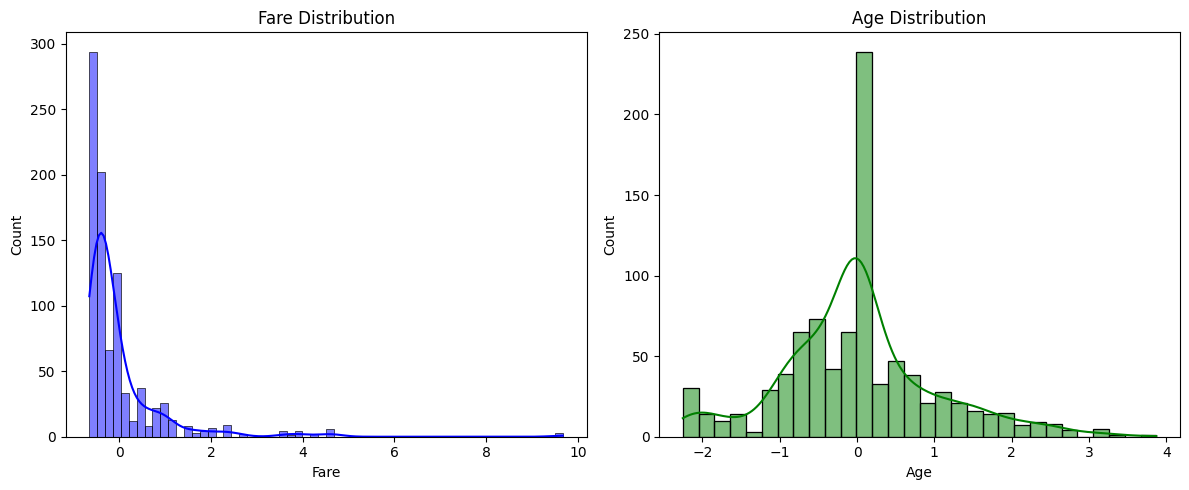

In [15]:
# 시각화로 왜도 분석

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Fare 분포
plt.subplot(1, 2, 1)
sns.histplot(df_train["Fare"], kde=True, color="blue")
plt.title("Fare Distribution")

# Age 분포
plt.subplot(1, 2, 2)
sns.histplot(df_train["Age"], kde=True, color="green")
plt.title("Age Distribution")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'After Log Transform')

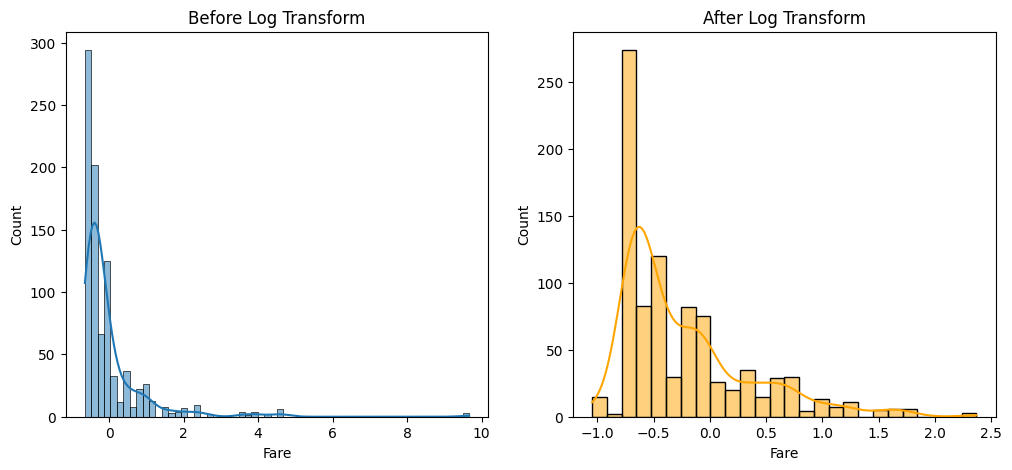

In [16]:
# 왜도 처리

import numpy as np

# 로그 변환 적용
fare_log = np.log1p(df_train["Fare"])

# 변환 전후 비교 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_train['Fare'], kde=True)
plt.title("Before Log Transform")

plt.subplot(1, 2, 2)
sns.histplot(fare_log, kde=True, color='orange')
plt.title(f"After Log Transform")

## 이상치 탐색 및 처리

In [17]:
# 이상치 탐색

from numpy._core.defchararray import upper

def get_outlier(df, column):
  Q1 = np.percentile(df[column], 25)
  Q3 = np.percentile(df[column], 75)

  IQR = Q3 - Q1

  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR

  outlier_indices = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index

  print(f"{column}의 경계값: [{lower_bound:.2f}, {upper_bound:.2f}]")
  print(f"{column}의 이상치 개수: {len(outlier_indices)}")

  return outlier_indices

# Age & Fare 이상치 확인
age_outliers = get_outlier(df_train, 'Age')
fare_outliers = get_outlier(df_train, 'Fare')

Age의 경계값: [-2.09, 1.91]
Age의 이상치 개수: 66
Fare의 경계값: [-1.19, 0.67]
Fare의 이상치 개수: 116


In [18]:
# 이상치 처리
# 경계값 고정 방식(Capping) 사용

def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 경계값을 벗어나는 데이터를 경계값으로 대체 (Capping)
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                          np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

# 이상치 처리 적용
df_train = handle_outliers(df_train, 'Age')
df_train = handle_outliers(df_train, 'Fare')

print("\n[처리 후 확인]")
print(f"Age 최대값: {df_train['Age'].max():.2f}")
print(f"Fare 최대값: {df_train['Fare'].max():.2f}")


[처리 후 확인]
Age 최대값: 1.91
Fare 최대값: 0.67


## 피처 선택 및 생성

In [19]:
# PassengerId, Name, Ticket 삭제
df_train = df_train.drop(["PassengerId", "Name", "Ticket"], axis=1)
df_train.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [20]:
# 새로운 피쳐 생성

# 가족 구성원 통합
df_train['FamilySize'] = df_train['SibSp'] + df_train["Parch"] +1

# 혼자 탑승했는지의 여부
df_train['IsAlone'] = 0
df_train.loc[df_train['FamilySize'] == 1, 'IsAlone'] = 1

# 인당 요금
df_train["FarePerPerson"] = df_train["Fare"] / df_train["FamilySize"]

df_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,FamilySize,IsAlone,FarePerPerson
0,0,3,-0.592481,1,0,-0.502445,0.0,1.0,0.0,0.0,1.0,2,0,-0.251223
1,1,1,0.638789,1,0,0.673106,1.0,0.0,1.0,0.0,0.0,2,0,0.336553
2,1,3,-0.284663,0,0,-0.488854,1.0,0.0,0.0,0.0,1.0,1,1,-0.488854
3,1,1,0.407926,1,0,0.420730,1.0,0.0,0.0,0.0,1.0,2,0,0.210365
4,0,3,0.407926,0,0,-0.486337,0.0,1.0,0.0,0.0,1.0,1,1,-0.486337
